Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'


Regime 0: Mean Return = 0.0006, Volatility = 0.0232
Regime 1: Mean Return = 0.0026, Volatility = 0.0543
Regime 2: Mean Return = 0.0310, Volatility = 0.1457
                  Ann. Return (%)  Volatility (%)  Sharpe Ratio  \
Buy & Hold             152.307299       87.009970      1.750458   
Oracle LO (2)           89.617209       70.126045      1.277945   
Oracle LS (2)           42.457367       87.177246      0.487023   
Oracle LO (3)           64.461375       54.189199      1.189561   
Oracle LS (3)           21.730995       82.030420      0.264914   
VM Oracle LO (2)         5.970622        6.948717      0.859241   
VM Oracle LS (2)         1.460421        9.934489      0.147005   
VM Oracle LO (3)         4.219507        4.678248      0.901942   
VM Oracle LS (3)         0.238185        8.723071      0.027305   
TSM LO                 152.744999       63.836265      2.392762   
TSM LS                 153.183456       87.008496      1.760557   
VM TSM LO               10.583945       

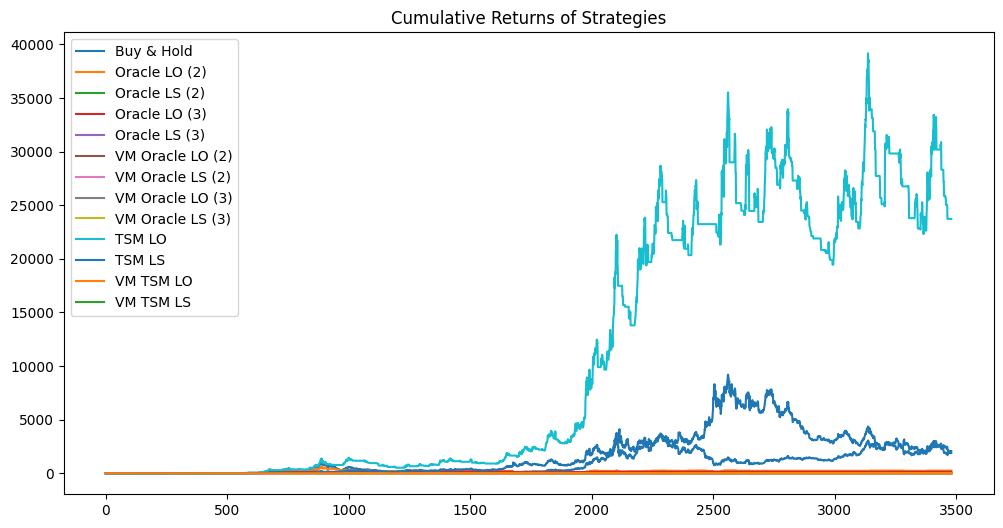

In [17]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt

# Step 1: Fetch Data
data = pd.read_csv("data/micro/candleData/ethereum_candles.csv").dropna(axis=0)
close_prices = data['close'].values

# Check for outliers or extreme values
if np.any(np.isnan(close_prices)) or np.any(close_prices <= 0):
    raise ValueError("Data contains NaN or non-positive prices. Please clean the data.")

returns = np.diff(close_prices) / close_prices[:-1]  # Daily returns

# Ensure enough data
if len(returns) < 50:  # Minimum for HMM stability
    raise ValueError("Not enough data points for meaningful HMM fit.")

# Step 2: Fit a 2-State MSM (Part 2)
model_2state = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000)  # Increased iterations
model_2state.fit(returns.reshape(-1, 1))
states_2 = model_2state.predict(returns.reshape(-1, 1))
proba_2 = model_2state.predict_proba(returns.reshape(-1, 1))

# Assign regimes based on mean returns
mean_returns_2 = [returns[states_2 == i].mean() for i in range(2)]
bull_state_2 = np.argmax(mean_returns_2)
bear_state_2 = np.argmin(mean_returns_2)
regimes_2 = np.where(states_2 == bull_state_2, 1, 2)

# Step 3: Fit a 3-State MSM with AR(2) (Part 3)
ar_model = AutoReg(returns, lags=2).fit()
ar_fitted = ar_model.predict(start=2, end=len(returns)-1)
residuals = returns[2:] - ar_fitted

# Initialize HMM with suggested means for better convergence (Bull, Bear, Chop)
initial_means = np.array([[0.01], [-0.01], [0.0]])  # Initial guess
model_3state = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=2000)  # Increased iterations
model_3state.means_ = initial_means
model_3state.fit(residuals.reshape(-1, 1))
states_3 = model_3state.predict(residuals.reshape(-1, 1))
proba_3 = model_3state.predict_proba(residuals.reshape(-1, 1))

# Align regimes_3 with returns by padding
states_3_full = np.concatenate(([states_3[0]]*2, states_3))  # Pad with first state
regime_stats = []
for i in range(3):
    regime_returns = returns[states_3_full == i]
    mean_ret = regime_returns.mean() if len(regime_returns) > 0 else 0
    vol = regime_returns.std() if len(regime_returns) > 0 else 0
    regime_stats.append((mean_ret, vol))

# Robust regime assignment
bull_idx = np.argmax([r for r, v in regime_stats])  # Highest mean return
neg_returns = [(i, v) for i, (r, v) in enumerate(regime_stats) if r < 0]
if neg_returns:
    bear_idx = max(neg_returns, key=lambda x: x[1])[0]  # Highest vol among negative returns
else:
    bear_idx = np.argmax([v if i != bull_idx else -np.inf for i, (r, v) in enumerate(regime_stats)])
chop_idx = [i for i in range(3) if i not in [bull_idx, bear_idx]][0]
regimes_3 = np.where(states_3_full == bull_idx, 1, np.where(states_3_full == bear_idx, 2, 3))

# Print regime stats for debugging
for i, (mean, vol) in enumerate(regime_stats):
    print(f"Regime {i}: Mean Return = {mean:.4f}, Volatility = {vol:.4f}")

# Step 4: Oracle Strategies
def compute_strategy_returns(returns, regimes, strategy_type):
    weights = np.zeros_like(returns)
    if strategy_type == "long_only_2":
        weights[1:] = np.where(regimes[:-1] == 1, 1, 0)
    elif strategy_type == "long_short_2":
        weights[1:] = np.where(regimes[:-1] == 1, 1, -1)
    elif strategy_type == "long_only_3":
        weights[1:] = np.where(regimes[:-1] == 1, 1, 0)
    elif strategy_type == "long_short_3":
        weights[1:] = np.where(regimes[:-1] == 1, 1, np.where(regimes[:-1] == 2, -1, 0))
    weights = np.clip(weights, -1.0, 1.0)  # Cap at ±1x for Oracle strategies
    return weights[1:] * returns[1:]

bh_returns = returns[1:]  # Buy & Hold capped at 1x
oracle_lo_2 = compute_strategy_returns(returns, regimes_2, "long_only_2")
oracle_ls_2 = compute_strategy_returns(returns, regimes_2, "long_short_2")
oracle_lo_3 = compute_strategy_returns(returns, regimes_3, "long_only_3")
oracle_ls_3 = compute_strategy_returns(returns, regimes_3, "long_short_3")

# Step 5: Volatility-Managed Oracle
def volatility_managed_returns(returns, regimes, strategy_type, target_vol=0.10, min_vol=0.005, max_weight=10.0):
    rolling_vol = pd.Series(returns).rolling(window=252, min_periods=1).std() * np.sqrt(252)
    rolling_vol = np.maximum(rolling_vol, min_vol)  # Prevent division by zero or tiny values
    weights_raw = np.zeros_like(returns)
    if strategy_type == "long_only_2":
        weights_raw[1:] = np.where(regimes[:-1] == 1, target_vol / rolling_vol[:-1], 0)
    elif strategy_type == "long_short_2":
        weights_raw[1:] = np.where(regimes[:-1] == 1, target_vol / rolling_vol[:-1], 
                                  -target_vol / rolling_vol[:-1])
    elif strategy_type == "long_only_3":
        weights_raw[1:] = np.where(regimes[:-1] == 1, target_vol / rolling_vol[:-1], 0)
    elif strategy_type == "long_short_3":
        weights_raw[1:] = np.where(regimes[:-1] == 1, target_vol / rolling_vol[:-1], 
                                  np.where(regimes[:-1] == 2, -target_vol / rolling_vol[:-1], 0))
    weights = np.clip(weights_raw, -max_weight, max_weight)  # Cap leverage at ±10x
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)  # Handle NaN/inf
    return weights[1:] * returns[1:]

vm_oracle_lo_2 = volatility_managed_returns(returns, regimes_2, "long_only_2")
vm_oracle_ls_2 = volatility_managed_returns(returns, regimes_2, "long_short_2")
vm_oracle_lo_3 = volatility_managed_returns(returns, regimes_3, "long_only_3")
vm_oracle_ls_3 = volatility_managed_returns(returns, regimes_3, "long_short_3")

# Step 6: TSM Strategies with Majority Voting
def tsm_signal(returns, lookback):
    cum_returns = pd.Series(returns).rolling(lookback, min_periods=1).apply(lambda x: np.prod(1 + x) - 1)
    return np.where(cum_returns >= 0, 1, 0)

tsm_signals = {n: tsm_signal(returns, n) for n in range(1, 25)}
majority_vote = np.mean([tsm_signals[n] for n in range(1, 25)], axis=0) >= 0.5
tsm_lo = np.clip(np.where(majority_vote[:-1], returns[1:], 0), -1.0, 1.0)  # Cap at ±1x
tsm_ls = np.clip(np.where(majority_vote[:-1], returns[1:], -returns[1:]), -1.0, 1.0)  # Cap at ±1x

# Volatility-Managed TSM
rolling_vol = pd.Series(returns).rolling(window=252, min_periods=1).std() * np.sqrt(252)
rolling_vol = np.maximum(rolling_vol, 0.005)  # Minimum volatility (reduced for more leverage)
weights_lo_raw = np.where(majority_vote[:-1], 0.10 / rolling_vol[:-1], 0)
weights_ls_raw = np.where(majority_vote[:-1], 0.10 / rolling_vol[:-1], -0.10 / rolling_vol[:-1])
vm_tsm_lo = np.clip(weights_lo_raw, -10.0, 10.0) * returns[1:]  # Cap at ±10x
vm_tsm_ls = np.clip(weights_ls_raw, -10.0, 10.0) * returns[1:]  # Cap at ±10x

# Step 7: Performance Metrics
def performance_metrics(returns):
    # Annualized return using compound formula
    ann_ret = ((1 + np.mean(returns)) ** 252 - 1) * 100 if np.isfinite(np.mean(returns)) else np.nan
    ann_vol = np.std(returns) * np.sqrt(252) * 100 if np.isfinite(np.std(returns)) else np.nan
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum_returns = np.cumprod(1 + returns) - 1
    max_dd = np.min(cum_returns - np.maximum.accumulate(cum_returns)) * 100 if len(cum_returns) > 0 else np.nan
    max_dd = np.clip(max_dd, -100.0, 0.0)  # Ensure drawdown is realistic (max -100%)
    return {"Ann. Return (%)": ann_ret, "Volatility (%)": ann_vol, 
            "Sharpe Ratio": sharpe, "Max Drawdown (%)": max_dd}

strategies = {
    "Buy & Hold": bh_returns,
    "Oracle LO (2)": oracle_lo_2,
    "Oracle LS (2)": oracle_ls_2,
    "Oracle LO (3)": oracle_lo_3,
    "Oracle LS (3)": oracle_ls_3,
    "VM Oracle LO (2)": vm_oracle_lo_2,
    "VM Oracle LS (2)": vm_oracle_ls_2,
    "VM Oracle LO (3)": vm_oracle_lo_3,
    "VM Oracle LS (3)": vm_oracle_ls_3,
    "TSM LO": tsm_lo,
    "TSM LS": tsm_ls,
    "VM TSM LO": vm_tsm_lo,
    "VM TSM LS": vm_tsm_ls
}

results = {name: performance_metrics(returns) for name, returns in strategies.items()}
results_df = pd.DataFrame(results).T
print(results_df)

# Plot
plt.figure(figsize=(12, 6))
for name, returns in strategies.items():
    plt.plot(np.cumprod(1 + returns), label=name)
plt.legend()
plt.title("Cumulative Returns of Strategies")
plt.show()

,date,open,high,low,close
2,2015-08-08,2.830000,2.830000,2.830000,2.830000
3,2015-08-09,1.330000,1.330000,1.330000,1.330000
4,2015-08-10,1.008793,1.008793,1.008793,1.008793
5,2015-08-11,0.687586,0.687586,0.687586,0.687586
6,2015-08-12,1.067000,1.067000,1.067000,1.067000
...,...,...,...,...,...
3480,2025-02-14,2737.200000,2754.380000,2619.670000,2675.710000
3481,2025-02-15,2676.720000,2785.500000,2668.560000,2724.670000
3482,2025-02-16,2725.890000,2737.020000,2681.980000,2692.820000
3483,2025-02-17,2693.500000,2717.500000,2659.000000,2659.900000
